In [2]:
pip install cleantext

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopy
import folium
from sklearn.preprocessing import StandardScaler
from geopy.geocoders import Nominatim, GoogleV3
from folium.plugins import MarkerCluster
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
import nltk
from textblob import TextBlob
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import nltk
from textblob import TextBlob
import re
import nltk
import string
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from cleantext import clean as cleaner
from sklearn.decomposition import TruncatedSVD

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
geo = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/geolocation_data_set.csv')
order = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/Review.csv')
cust = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/olist_public_dataset_v2_customers.csv')
pay = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/payment data.csv')
trans = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/Translation.csv')

## Geo Location Exploration

In [6]:
geo.head()

,zip_code_prefix,city,state,lat,lng
0,10,sao paulo,sp,-23.547807,-46.636122
1,10,sao paulo,sp,-23.546081,-46.644820
2,10,sao paulo,sp,-23.540984,-46.642569
3,10,sao paulo,sp,-23.546758,-46.645771
4,10,sao paulo,sp,-23.546362,-46.643073


In [7]:
geo = geo.drop_duplicates(subset=None, keep='first', inplace=False)

In [8]:
centroid = geo.groupby('zip_code_prefix').agg({
    'lat': 'median',
    'lng': 'median',
    'city': pd.Series.mode
}).reset_index()
centroid['count'] = geo.groupby('zip_code_prefix').size().reset_index(
    name='counts')['counts']

In [9]:
import plotly
import plotly.express as px

token = 'pk.eyJ1IjoiZmFhdGhpcjk4IiwiYSI6ImNrMGVxMTl5dzBiZHYzYm1wMm15b2RhcXQifQ.InHG7-SGeNMtnnfkvIVCRg'
fig = px.scatter_mapbox(centroid,
                        lat="lat",
                        lon="lng",
                        size="count",
                        color="count",
                        size_max=8,
                        color_continuous_scale=px.colors.sequential.Redor,
                        zoom=2.7)
fig.update_layout(mapbox_style="outdoors", mapbox_accesstoken=token)
fig.show()

## Revenue Distribution

In [10]:
order.head()

,order_id,order_status,order_products_value,order_freight_value,order_items_qty,order_sellers_qty,order_purchase_timestamp,order_aproved_at,order_estimated_delivery_date,order_delivered_customer_date,...,product_name_lenght,product_description_lenght,product_photos_qty,product_id,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,b95df3cef5297e79ef709ba256518f6f,delivered,349.90,13.84,1,1,2017-01-31 17:19:01.000000,2017-02-01 02:41:21.549551,2017-03-15 00:00:00.000000,2017-02-06 11:04:24.154259,...,51,625,1,6cdd53843498f92890544667809f1595,b95df3cef5297e79ef709ba256518f6f,5,NaN,NaN,2017-02-07 00:00:00.000000,2017-02-09 02:37:37+00:00
1,59af46052a799e80e2f0c665c587731d,delivered,15.00,15.10,1,1,2017-09-09 19:52:54.000000,2017-09-10 20:03:31.535281,2017-10-02 00:00:00.000000,2017-09-13 20:17:41.296915,...,44,1428,2,ae5cad88462eb7b7b61401e31c45618e,59af46052a799e80e2f0c665c587731d,5,NaN,entrega em 2 dias produto c boa qualidade otim...,2017-09-14 00:00:00.000000,2017-09-15 03:43:47+00:00
2,a3e6136894621db402a772c6bc72a12a,delivered,238.90,18.00,1,1,2017-01-30 17:00:09.000000,2017-01-30 17:31:25.438253,2017-03-07 00:00:00.000000,2017-02-06 15:43:04.758566,...,55,637,1,0c9ff9d8ed9b9bdd825487b3a66e05f5,a3e6136894621db402a772c6bc72a12a,5,NaN,produto veio antes do prazo informado muito ob...,2017-02-07 00:00:00.000000,2017-02-10 14:18:53+00:00
3,b675ea5a618922f6e679e30531b8957b,delivered,29.99,18.23,1,1,2018-03-11 18:18:36.000000,2018-03-11 18:30:37.931962,2018-04-03 00:00:00.000000,2018-04-03 20:36:43.778451,...,55,617,1,ad0a798e7941f3a5a2fb8139cb62ad78,b675ea5a618922f6e679e30531b8957b,4,NaN,NaN,2018-04-04 00:00:00.000000,2018-04-05 02:52:31+00:00
4,195a8be6794c487fe6cfbb97b7c61902,delivered,295.99,47.65,1,1,2017-04-20 08:01:08.000000,2017-04-25 08:05:40.405383,2017-05-24 00:00:00.000000,2017-05-04 18:47:45.721758,...,49,558,2,eaf2046d4c87809247a30050ea13df03,195a8be6794c487fe6cfbb97b7c61902,5,NaN,NaN,2017-05-05 00:00:00.000000,2017-05-08 15:20:18+00:00


In [11]:
order = order.drop_duplicates(subset=None, keep='first', inplace=False)

In [12]:
geo_order = pd.merge(centroid,
                     order,
                     how='right',
                     left_on='zip_code_prefix',
                     right_on='customer_zip_code_prefix')
# Merging the 'centroid' DataFrame with the 'order' DataFrame.
# This merge is performed on 'zip_code_prefix' from 'centroid' and 'customer_zip_code_prefix' from 'order'.
# A right merge is used to keep all orders and add geographic information where available.

In [13]:
geo_rev = geo_order.groupby('customer_zip_code_prefix').agg({
    'lat':
    'median',
    'lng':
    'median',
    'order_products_value':
    'sum'
}).reset_index()

In [14]:
import plotly.graph_objects as go
fig = go.Figure(
    go.Densitymapbox(lat=geo_rev.lat,
                     lon=geo_rev.lng,
                     z=geo_rev.order_products_value,
                     radius=10))
fig.update_layout(mapbox_style="stamen-terrain",
                  mapbox_center_lon=-50,
                  mapbox_center_lat=-16,
                  mapbox_zoom=2.7)
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

## Customer Distribution

In [15]:
geo_order = geo_order.dropna(subset=['zip_code_prefix'])
geo_cust = geo_order.groupby('customer_zip_code_prefix').agg({
    'lat':
    'median',
    'lng':
    'median',
    'customer_id':
    'count'
}).reset_index()

In [16]:
import plotly.graph_objects as go
fig = go.Figure(
    go.Densitymapbox(lat=geo_cust.lat,
                     lon=geo_cust.lng,
                     z=geo_cust.customer_id,
                     radius=10))
fig.update_layout(mapbox_style="stamen-terrain",
                  mapbox_center_lon=-50,
                  mapbox_center_lat=-16,
                  mapbox_zoom=2.7)
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

# Time Period Exploration

In [17]:
geo_order['order_delivered_customer_date'] = pd.to_datetime(
    geo_order['order_delivered_customer_date'])
geo_order['order_estimated_delivery_date'] = pd.to_datetime(
    geo_order['order_estimated_delivery_date'])

#### Analyzing Delivery Time Variation

This section calculates the difference between the actual and estimated delivery dates to determine if orders were delayed or delivered early. It then categorizes these differences into bins for better analysis.

In [18]:
geo_order = geo_order.dropna(subset=['order_delivered_customer_date'])

In [19]:
geo_order['order_delivered_customer_date'] = pd.to_datetime(geo_order['order_delivered_customer_date'])
geo_order['order_estimated_delivery_date'] = pd.to_datetime(geo_order['order_estimated_delivery_date'])

geo_order['range_time'] = (
    geo_order['order_delivered_customer_date'] -
    geo_order['order_estimated_delivery_date']
).dt.days

After converting the delivery and estimated delivery dates to datetime objects, the `range_time` column is created to capture the difference in days. Positive values indicate delays, while negative values indicate early deliveries.

In [20]:
delay = geo_order['range_time'][geo_order['range_time'] > 0]
early = abs(geo_order['range_time'][geo_order['range_time'] < 0])

The `delay` series isolates orders that were delivered after the estimated date, and `early` isolates orders delivered before the estimated date. The absolute value is taken for early deliveries to represent the number of days early.

In [21]:
bins = [0, 3, 7, 14, 30, 90]
labels = [
    '1-3 days', '4-7 days', '7-14 days', '14-30 days', 'More than 1 month'
]
early = pd.cut(early, bins=bins, labels=labels)

Here, `early` delivery times are categorized into predefined bins (1-3 days, 4-7 days, etc.) to understand the distribution of early deliveries.

<Axes: xlabel='count', ylabel='range_time'>

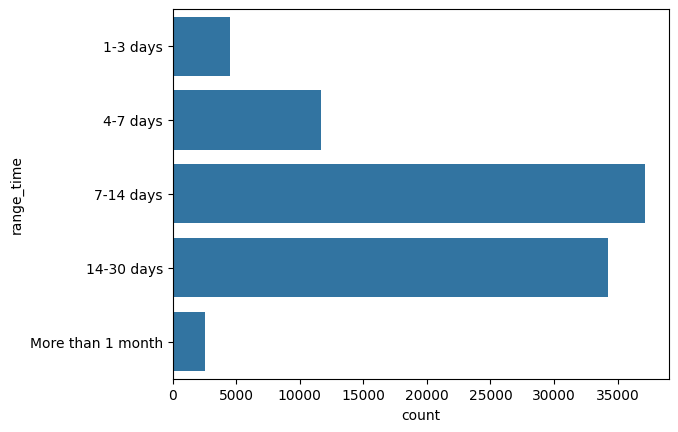

In [22]:
sns.countplot(y=early)

This bar plot visualizes the distribution of early deliveries across the defined categories, showing how many orders arrived ahead of schedule within each time frame.

In [23]:
bins = [0, 3, 7, 14, 30, 90, 300]
labels = [
    '1-3 days', '4-7 days', '7-14 days', '14-30 days', '1-3 month',
    'More than 3 months'
]
delay = pd.cut(delay, bins=bins, labels=labels)

Similarly, `delay` delivery times are categorized into bins to understand the distribution of delayed deliveries. The bins are extended to include longer delays.

<Axes: xlabel='count', ylabel='range_time'>

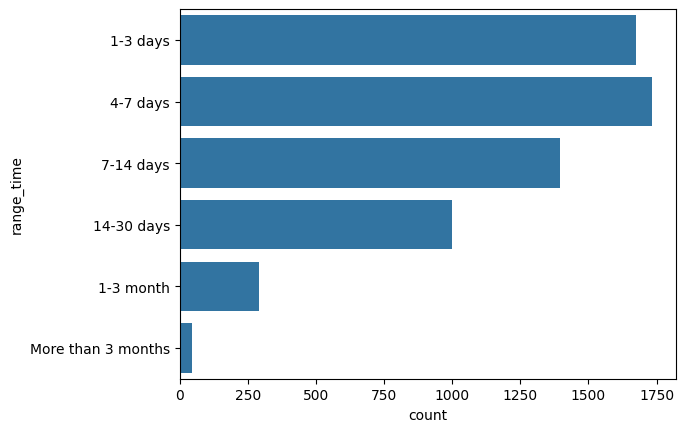

In [24]:
sns.countplot(y=delay)

This bar plot visualizes the distribution of delayed deliveries across the defined categories, showing how many orders were delayed within each time frame.

In [25]:
geo_order['range_time_default'] = geo_order['range_time'].apply(
    lambda x: 1 if x > 0 else 0)

The `range_time_default` column is created as a binary indicator (1 for delayed, 0 for on-time/early) to easily count and visualize delay occurrences.

In [26]:
delay_place = geo_order.groupby('zip_code_prefix').agg({
    'lat':
    'median',
    'lng':
    'median',
    'range_time_default':
    'mean'
})

The `delay_place` DataFrame aggregates the median latitude, longitude, and the mean of `range_time_default` by `zip_code_prefix`. This helps identify geographical areas with higher proportions of delayed deliveries.

In [27]:
fig = go.Figure(
    go.Densitymapbox(lat=delay_place.lat,
                     lon=delay_place.lng,
                     z=delay_place.range_time_default,
                     radius=10))
fig.update_layout(mapbox_style="stamen-terrain",
                  mapbox_center_lon=-50,
                  mapbox_center_lat=-16,
                  mapbox_zoom=2.8)
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

This density map visualizes the geographical distribution of delivery delays. Areas with higher density indicate regions where a larger percentage of deliveries experience delays.

In [28]:
normal = geo_order['range_time'][geo_order['range_time'] == 0]
print('normal:',
      round(normal.count() * 100 / geo_order['range_time'].count(),
            3), '%', '\nearly:',
      round(early.count() * 100 / geo_order['range_time'].count(), 3), '%',
      '\ndelay:',
      round(delay.count() * 100 / geo_order['range_time'].count(), 3), '%')

normal: 1.259 % 
early: 92.44 % 
delay: 6.293 %


This calculation provides a summary of the percentage of orders that were delivered on time, early, or delayed, offering a high-level overview of delivery performance.

# Promotion Timing

In [29]:
order['order_purchase_timestamp'] = pd.to_datetime(
    order['order_purchase_timestamp'])

#### Analyzing Order Purchase Timings

This section explores the distribution of order purchase timestamps to identify optimal hours, days, and months for potential promotional activities.

In [30]:
best_time_hours = (order.order_purchase_timestamp).dt.hour

The hour of the day when orders are placed is extracted from the `order_purchase_timestamp` column. This helps identify peak purchasing hours.

/tmp/ipykernel_12866/57213417.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='order_purchase_timestamp', ylabel='Density'>

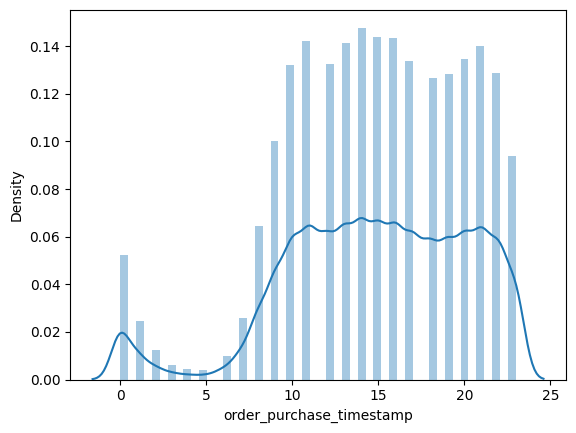

In [31]:
sns.distplot(best_time_hours)

This distribution plot visualizes the frequency of orders across different hours of the day. Peaks indicate popular times for customers to make purchases.

In [32]:
best_time_day = order.order_purchase_timestamp.apply(lambda x: x.weekday())

The day of the week when orders are placed is extracted (0 for Monday, 6 for Sunday). This helps identify peak purchasing days.

/tmp/ipykernel_12866/886976007.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='order_purchase_timestamp', ylabel='Density'>

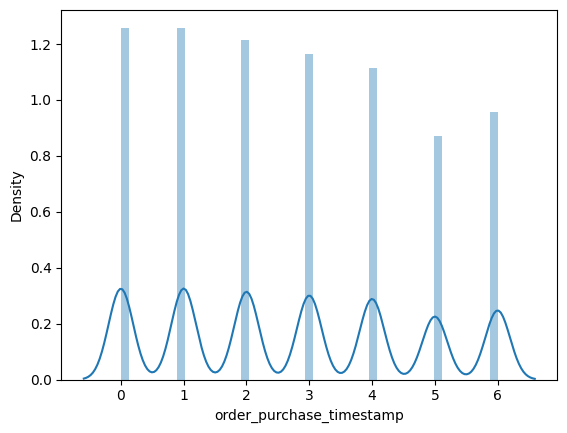

In [33]:
sns.distplot(best_time_day)

This distribution plot visualizes the frequency of orders across different days of the week, helping to identify the busiest shopping days.

In [34]:
best_time_month = (order.order_purchase_timestamp).dt.month

The month of the year when orders are placed is extracted. This helps identify peak purchasing months, potentially influenced by seasonal sales or holidays.

/tmp/ipykernel_12866/471846803.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='order_purchase_timestamp', ylabel='Density'>

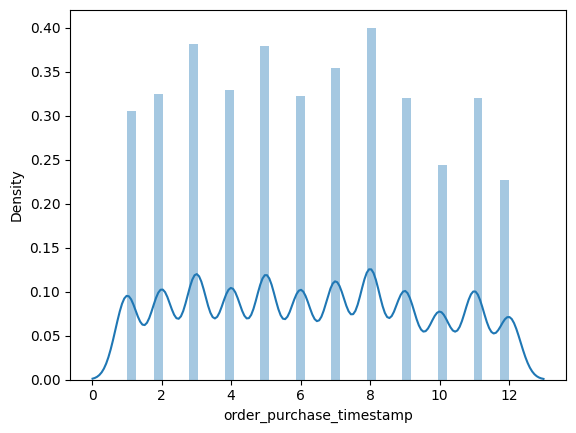

In [35]:
sns.distplot(best_time_month)

This distribution plot visualizes the frequency of orders across different months of the year, highlighting seasonal purchasing trends.

# Customer Behaviour Exploration

In [36]:
cust.head()

,customer_id,customer_unique_id
0,0000ca4ff2795842fd6b122c6d974468,ac0e5d7f07043dd32831bdad3b99ad26
1,00010f206878ba01f199aec4237de72e,4ed24aaed4079fe0661c0e4b3b420dff
2,00012a2ce6f8dcda20d059ce98491703,7e0e291c0f4fc2d69208954d26ed0586
3,000161a058600d5901f007fab4c27140,ff1dcb27ea444eddb94ea5fea77b875c
4,00017f1d6cce0d56046219a2cfabcbbb,237130c4b6717031ed62d9d0b16fd94f


In [37]:
cust = cust.drop_duplicates(subset=None, keep='first', inplace=False)

In [38]:
order_cust = pd.merge(order, cust, on='customer_id', how='inner')
order_cust['order_purchase_timestamp'] = pd.to_datetime(order_cust['order_purchase_timestamp'])

In [39]:
import pandas as pd

# Ensure datetime format
order_cust['order_purchase_timestamp'] = pd.to_datetime(order_cust['order_purchase_timestamp'])

# Reference date (usually max date in dataset)
reference_date = order_cust['order_purchase_timestamp'].max()

# Create range_time (timedelta)
order_cust['range_time'] = reference_date - order_cust['order_purchase_timestamp']

In [40]:
recent = order_cust.groupby('customer_unique_id').agg(
    recency=('range_time', lambda x: x.min().days)
)

In [41]:
frequent = order_cust.groupby('customer_unique_id').agg(
    {'order_items_qty': 'sum'})

In [42]:
monetary = order_cust.groupby('customer_unique_id').agg(
    {'order_products_value': 'sum'})

In [43]:
tenure = order_cust.groupby('customer_unique_id').agg(
    tenure=('range_time', 'max')
)

tenure['tenure'] = tenure['tenure'].dt.days

### RFMT Segmentation

RFMT (Recency, Frequency, Monetary, Tenure) analysis is a marketing technique used to quantitatively rank and group customers based on their purchasing behavior. It segments customers into groups such as best customers, loyal customers, at-risk customers, etc., allowing for targeted marketing strategies.

- **Recency (R):** How recently did the customer make a purchase?
- **Frequency (F):** How often do they purchase?
- **Monetary (M):** How much money do they spend?
- **Tenure (T):** How long has the customer been active?

Below, we calculate these metrics and assign scores (1-5) to each customer based on quintiles for Recency, Frequency, Monetary, and Tenure values.

In [44]:
rfmt = pd.concat([recent, frequent, monetary, tenure], axis=1)
rfmt.columns = ['recency', 'frequency', 'monatary', 'tenure']

### Assigning RFMT Scores

Customers are ranked based on their Recency, Frequency, Monetary, and Tenure values. For Recency, lower values (more recent purchases) get higher scores (5 is best). For Frequency, Monetary, and Tenure, higher values get higher scores (5 is best). These scores are then used to define different customer segments.

In [45]:
rfmt.describe()

,recency,frequency,monatary,tenure
count,92516.000000,92516.000000,92516.000000,92516.000000
mean,307.527909,1.189081,139.642552,310.652136
std,157.706448,0.668332,212.630906,157.850753
min,0.000000,1.000000,2.000000,0.000000
25%,188.000000,1.000000,49.000000,191.000000
50%,306.000000,1.000000,89.900000,307.000000
75%,429.000000,1.000000,155.377500,433.000000
max,753.000000,25.000000,14776.000000,753.000000


In [46]:
label1 = [5, 4, 3, 2, 1]
label2 = [1, 2, 3, 4, 5]
rfmt['R'] = pd.qcut(rfmt['recency'],
                    q=[0, 0.2, 0.4, 0.6, 0.8, 1],
                    labels=label1)
rfmt['F'] = pd.cut(rfmt['frequency'], bins=[0, 1, 2, 3, 5, 900], labels=label2)
rfmt['M'] = pd.qcut(rfmt['monatary'],
                    q=[0, 0.2, 0.4, 0.6, 0.8, 1],
                    labels=label2)
rfmt['T'] = pd.qcut(rfmt['tenure'],
                    q=[0, 0.2, 0.4, 0.6, 0.8, 1],
                    labels=label2)

### Customer Segmentation Based on RFMT Scores

Using the calculated R, F, M, and T scores, customers are classified into various segments to identify their value and behavior patterns. Each segment represents a distinct group for targeted marketing and customer retention efforts.

In [47]:
rfmt = rfmt.reset_index()

In [48]:
best = rfmt[rfmt.R.isin([4, 5]) & rfmt.F.isin([4, 5]) & rfmt.M.isin([4, 5])]
best['segment'] = 'BEST'

/tmp/ipykernel_12866/3546318883.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Loyal Spender Segment

This segment includes customers with high recency and monetary scores, moderate frequency, and long tenure. These are valuable customers who frequently spend and have been with the business for a considerable period.

In [49]:
loyal_spender = rfmt[rfmt['R'].isin([4, 5]) & rfmt['F'].isin([2, 3])
                     & rfmt['M'].isin([2, 3]) & rfmt['T'].isin([3, 4, 5])]
loyal_spender['segment'] = 'LOYAL SPENDER'

/tmp/ipykernel_12866/658045858.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Potential Loyal Segment

Customers in this segment have good recency and monetary scores, moderate frequency, but a shorter tenure. They show potential to become loyal customers with appropriate engagement strategies.

In [50]:
potential_loyal = rfmt[rfmt['R'].isin([4, 5]) & rfmt['F'].isin([2, 3])
                       & rfmt['M'].isin([2, 3]) & rfmt['T'].isin([1, 2])]
potential_loyal['segment'] = 'POTENTIAL LOYAL'

/tmp/ipykernel_12866/798796110.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### New Customer Segment

This segment comprises recent customers with low frequency and monetary scores and short tenure. These customers have just made their first purchase and are crucial for onboarding and initial engagement.

In [51]:
new_cust = rfmt[rfmt['R'].isin([4, 5]) & rfmt['F'].isin([1])
                & rfmt['M'].isin([1]) & rfmt['T'].isin([1, 2])]
new_cust['segment'] = 'NEW CUSTOMER'

/tmp/ipykernel_12866/547541769.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Loyal Customer Segment

Customers in this segment have good recency, low frequency and monetary scores, but a long tenure. They might not spend much or often, but they have a long-standing relationship with the business.

In [52]:
loyal_cust = rfmt[rfmt['R'].isin([4, 5]) & rfmt['F'].isin([1])
                  & rfmt['M'].isin([1]) & rfmt['T'].isin([3, 5])]
loyal_cust['segment'] = 'LOYAL CUSTOMER'

#### Promising Segment

This segment consists of customers with moderate recency but high frequency and monetary scores. They are promising as they spend well and often, and could become loyal with continued engagement.

In [53]:
promising = rfmt[rfmt['R'].isin([2, 3]) & rfmt['F'].isin([3, 5])
                 & rfmt['M'].isin([3, 5])]
promising['segment'] = 'PROMISING'

/tmp/ipykernel_12866/2619193638.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Can't Lose Segment

These customers have low recency, but high frequency and monetary scores. They haven't purchased recently but were valuable in the past, indicating a risk of churn but a high potential for reactivation.

In [54]:
cant_lose = rfmt[rfmt['R'].isin([1]) & rfmt['F'].isin([4, 5])
                 & rfmt['M'].isin([4, 5])]
cant_lose['segment'] = 'CAN NOT LOSE'

/tmp/ipykernel_12866/345917324.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### About to Sleep Segment

Similar to 'Can't Lose', these customers have low recency but high frequency and monetary scores. They are showing signs of inactivity and are at risk of churning.

In [55]:
about_to_sleep = rfmt[rfmt['R'].isin([1]) & rfmt['F'].isin([4, 5])
                      & rfmt['M'].isin([4, 5])]
about_to_sleep['segment'] = 'ABOUT TO SLEEP'

/tmp/ipykernel_12866/2559364249.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Hibernating Segment

Customers in this segment have low recency, moderate frequency, and moderate monetary scores. They have become inactive and require strong re-engagement strategies.

In [56]:
hibernating = rfmt[rfmt['R'].isin([1]) & rfmt['F'].isin([2, 3])
                   & rfmt['M'].isin([2, 3])]
hibernating['segment'] = 'HIBERNATING'

/tmp/ipykernel_12866/1389198173.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Lost Segment

This segment represents customers with low recency, frequency, monetary scores, and short tenure. These are newly inactive customers who are likely to be lost if not re-engaged immediately.

In [57]:
lost = rfmt[rfmt['R'].isin([1]) & rfmt['F'].isin([1]) & rfmt['M'].isin([1])
            & rfmt['T'].isin([1])]
lost['segment'] = 'HIBERNATING'

In [58]:
rfmt_segment = pd.concat([
    best, loyal_spender, potential_loyal, new_cust, loyal_cust, promising,
    cant_lose, about_to_sleep, hibernating, lost
])

In [59]:
rfmt_segment.sample(10)

,customer_unique_id,recency,frequency,monatary,tenure,R,F,M,T,segment
71023,c4a8b8379d31dee59a19627a242b9284,528,2,71.40,528,1,2,3,5,HIBERNATING
74523,ce4df8e6ba3d9aa511c682eb9a1dd655,123,1,39.99,123,5,1,1,1,NEW CUSTOMER
21272,3aa43a036ad6ca71c80bdd51c8fc02fc,478,2,83.80,478,1,2,3,5,HIBERNATING
8048,165dfb987fdf08d2a4292b1a14035a17,162,1,17.33,162,4,1,1,1,NEW CUSTOMER
52119,8fe886da808ca491be9bd93b1935d879,457,3,459.68,457,2,3,5,4,PROMISING
9958,1b90e6ff94d339de59749ecf47b70308,38,1,27.19,38,5,1,1,1,NEW CUSTOMER
57598,9f43f0459c152924a70f0a1742067a56,186,3,105.00,186,4,3,3,2,POTENTIAL LOYAL
9426,1a2e94a8da661c14317f781aa0ed8afe,493,2,91.80,493,1,2,3,5,HIBERNATING
72395,c86b833e5817407144f3c5b6bff8ad59,132,1,28.00,132,5,1,1,1,NEW CUSTOMER
29721,522247420b775aa2af8df02cc6e6292e,64,1,24.99,64,5,1,1,1,NEW CUSTOMER


# Product Exploration

### Popularity Analysis

In [60]:
trans.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [61]:
order_en = pd.merge(trans,
                       order,
                       how='right',
                       on=['product_category_name', 'product_category_name'])
# Merging the 'trans' (translation) DataFrame with the 'order' DataFrame.
# This merge is performed on 'product_category_name' to link product categories with their English translations.
# A right merge is used to ensure all orders are kept, and translations are added where matching.

In [62]:
order_en.head()

,product_category_name,product_category_name_english,order_id,order_status,order_products_value,order_freight_value,order_items_qty,order_sellers_qty,order_purchase_timestamp,order_aproved_at,...,product_name_lenght,product_description_lenght,product_photos_qty,product_id,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,beleza_saude,health_beauty,b95df3cef5297e79ef709ba256518f6f,delivered,349.90,13.84,1,1,2017-01-31 17:19:01,2017-02-01 02:41:21.549551,...,51,625,1,6cdd53843498f92890544667809f1595,b95df3cef5297e79ef709ba256518f6f,5,NaN,NaN,2017-02-07 00:00:00.000000,2017-02-09 02:37:37+00:00
1,informatica_acessorios,computers_accessories,59af46052a799e80e2f0c665c587731d,delivered,15.00,15.10,1,1,2017-09-09 19:52:54,2017-09-10 20:03:31.535281,...,44,1428,2,ae5cad88462eb7b7b61401e31c45618e,59af46052a799e80e2f0c665c587731d,5,NaN,entrega em 2 dias produto c boa qualidade otim...,2017-09-14 00:00:00.000000,2017-09-15 03:43:47+00:00
2,automotivo,auto,a3e6136894621db402a772c6bc72a12a,delivered,238.90,18.00,1,1,2017-01-30 17:00:09,2017-01-30 17:31:25.438253,...,55,637,1,0c9ff9d8ed9b9bdd825487b3a66e05f5,a3e6136894621db402a772c6bc72a12a,5,NaN,produto veio antes do prazo informado muito ob...,2017-02-07 00:00:00.000000,2017-02-10 14:18:53+00:00
3,cama_mesa_banho,bed_bath_table,b675ea5a618922f6e679e30531b8957b,delivered,29.99,18.23,1,1,2018-03-11 18:18:36,2018-03-11 18:30:37.931962,...,55,617,1,ad0a798e7941f3a5a2fb8139cb62ad78,b675ea5a618922f6e679e30531b8957b,4,NaN,NaN,2018-04-04 00:00:00.000000,2018-04-05 02:52:31+00:00
4,moveis_decoracao,furniture_decor,195a8be6794c487fe6cfbb97b7c61902,delivered,295.99,47.65,1,1,2017-04-20 08:01:08,2017-04-25 08:05:40.405383,...,49,558,2,eaf2046d4c87809247a30050ea13df03,195a8be6794c487fe6cfbb97b7c61902,5,NaN,NaN,2017-05-05 00:00:00.000000,2017-05-08 15:20:18+00:00


/tmp/ipykernel_12866/2449992933.py:17: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_12866/2449992933.py:20: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



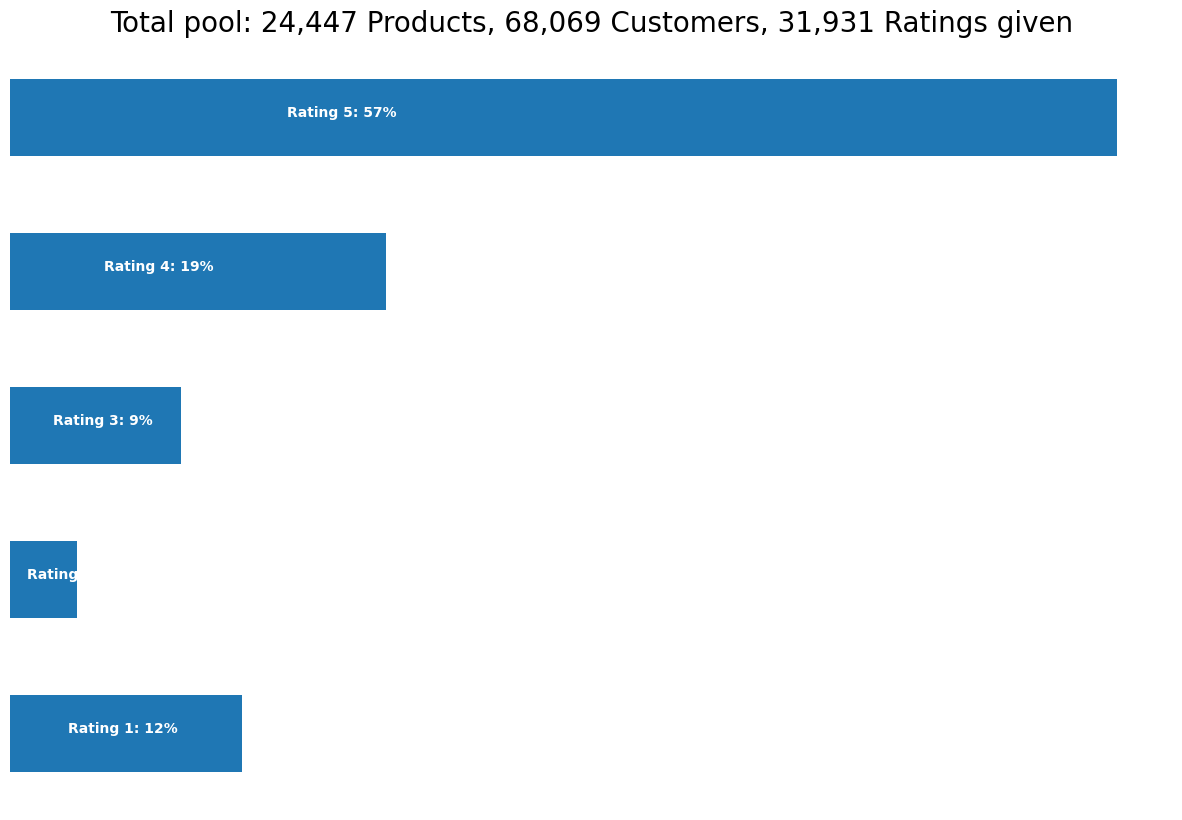

In [63]:
n = order_en.groupby('review_score')['review_score'].agg(['count'])

prod_count = order_en['product_id'].nunique()

cust_count = cust['customer_unique_id'].nunique() - prod_count

rating_count = order_en['review_score'].count() - cust_count

ax = n.plot(kind='barh', legend=False, figsize=(15, 10))
plt.title(
    'Total pool: {:,} Products, {:,} Customers, {:,} Ratings given'.format(
        prod_count, cust_count, rating_count),
    fontsize=20)
plt.axis('off')

for i in range(1, 6):
    ax.text(n.iloc[i - 1][0] / 4,
            i - 1,
            'Rating {}: {:.0f}%'.format(i,
                                        n.iloc[i - 1][0] * 100 / n.sum()[0]),
            color='white',
            weight='bold')

In [64]:
pop_prod = pd.DataFrame(
    order_en.groupby('product_id')['review_score'].count())
most_popular = pop_prod.sort_values('review_score', ascending=False)
most_popular.head(10)

,review_score
product_id,
99a4788cb24856965c36a24e339b6058,653
aca2eb7d00ea1a7b8ebd4e68314663af,615
422879e10f46682990de24d770e7f83d,475
d1c427060a0f73f6b889a5c7c61f2ac4,449
389d119b48cf3043d311335e499d9c6b,435
53759a2ecddad2bb87a079a1f1519f73,432
53b36df67ebb7c41585e8d54d6772e08,427
368c6c730842d78016ad823897a372db,380
2b4609f8948be18874494203496bc318,368


<Axes: ylabel='product_id'>

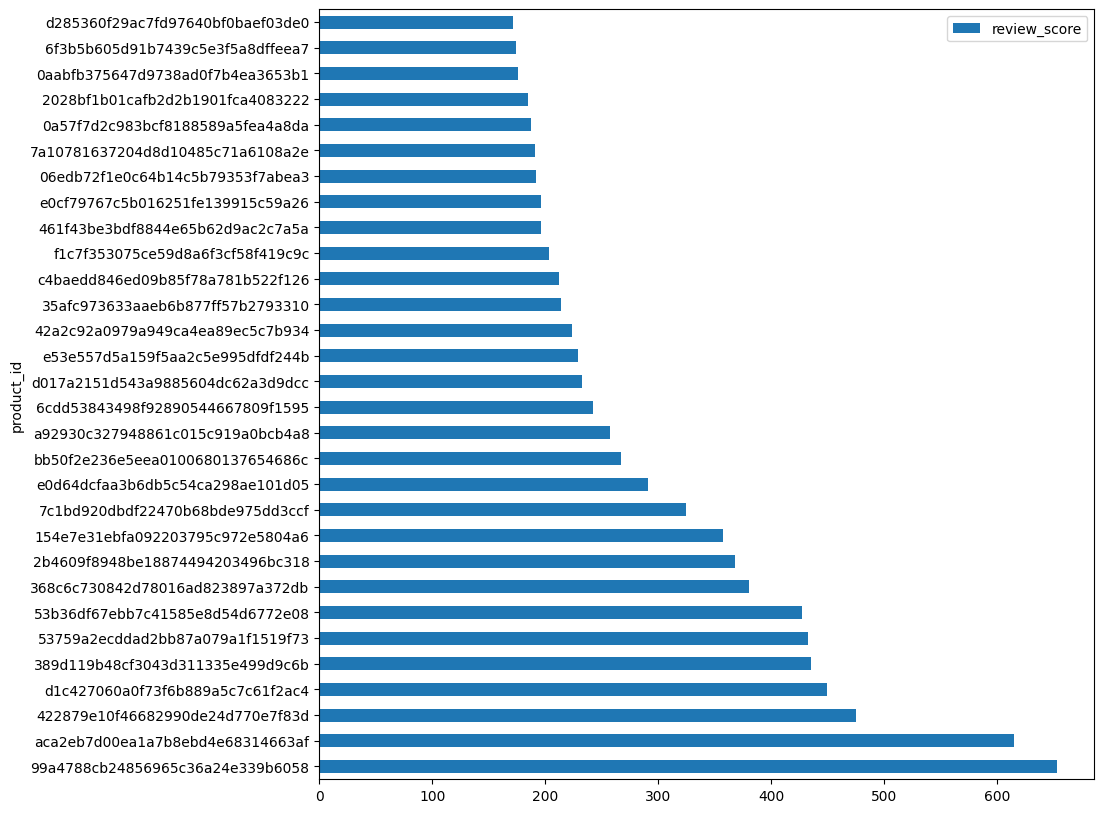

In [65]:
plt.rcParams['figure.figsize'] = (10, 10)
most_popular.head(30).plot(kind="barh")

## Sentiment Analysis

In [66]:
data = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/reviews_translated.csv')

In [67]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [68]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [69]:
default_stemmer = PorterStemmer()
default_stopwords = stopwords.words(
    'english')  # or any other list of your choice


def clean_text(text, ):
    def tokenize_text(text):
        return [w for s in sent_tokenize(text) for w in word_tokenize(s)]

    def remove_special_characters(text,
                                  characters=string.punctuation.replace(
                                      '-', '')):
        tokens = tokenize_text(text)
        pattern = re.compile('[{}]'.format(re.escape(characters)))
        return ' '.join(filter(None, [pattern.sub('', t) for t in tokens]))

    def remove_stopwords(text, stop_words=default_stopwords):
        tokens = [w for w in tokenize_text(text) if w not in stop_words]
        return ' '.join(tokens)

    text = text.strip(' ')  # strip whitespaces
    text = text.lower()  # lowercase
    text = remove_special_characters(text)  # remove punctuation and symbols
    #text.strip(' ') # strip whitespaces again?

    return text

In [70]:
def isNaN(num):
    return num != num


def sentimen_en(text):
    if isNaN(text) == True:
        return np.nan
    else:
        hasil = TextBlob(text).sentiment[0]
        return hasil

In [71]:
col = 'translate'  # change if needed

if col in data.columns:
    data['clean'] = data[col].apply(
        lambda x: clean_text(cleaner(str(x))) if pd.notnull(x) else ''
    )
else:
    print(f"Column '{col}' not found. Available columns:", data.columns)

Column 'translate' not found. Available columns: Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'review_comment_translated'],
      dtype='object')


In [72]:
# Clean column creation
col = 'your_column'  # change this

if col in data.columns:
    data['clean'] = data[col].apply(
        lambda x: clean_text(cleaner(str(x))) if pd.notnull(x) else ''
    )
else:
    print("Column not found:", data.columns)

# Sentiment
if 'clean' in data.columns:
    data['sentimen'] = data['clean'].apply(
        lambda x: sentimen_en(x) if pd.notnull(x) else 'neutral'
    )

Column not found: Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'review_comment_translated'],
      dtype='object')


In [73]:
if 'translate' in data.columns:
    mask = data['translate'].notna()
else:
    print("Column not found:", data.columns)

Column not found: Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'review_comment_translated'],
      dtype='object')


In [74]:
# Check columns first
print(data.columns)

# Create mask safely
if 'translate' in data.columns:
    mask = data['translate'].notna()
else:
    print("Column 'translate' not found")

# Sample only if columns exist
if all(col in data.columns for col in ['clean','sentimen']):
    print(data.loc[mask, ['clean','sentimen']].sample(10))
else:
    print("Missing columns:", data.columns)

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'review_comment_translated'],
      dtype='object')
Column 'translate' not found
Missing columns: Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'review_comment_translated'],
      dtype='object')


In [75]:
col_to_translate = 'review_comment_translated'

# Ensure the cleaning and sentiment columns are created before cutting
if col_to_translate in data.columns:
    data['clean'] = data[col_to_translate].apply(
        lambda x: clean_text(cleaner(str(x))) if pd.notnull(x) else ''
    )
else:
    print(f"Column '{col_to_translate}' not found. Cannot perform sentiment analysis.")
    data['clean'] = '' # Initialize clean to avoid further errors

# Sentiment calculation
if 'clean' in data.columns:
    data['sentimen'] = data['clean'].apply(
        lambda x: sentimen_en(x) if pd.notnull(x) else 0.0 # Changed 'neutral' to 0.0 for numerical consistency
    )
else:
    data['sentimen'] = 0.0 # Initialize sentimen to avoid further errors

# Create sentiment label
bins = [-1, -0.3, 0.3, 1]
labels = ['negative', 'unsure', 'positive']
data['sentimen_label'] = pd.cut(
    data['sentimen'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [76]:
bins = [-1, -0.3, 0.3, 1]
labels = ['negative', 'unsure', 'positive']
data['sentimen_label'] = pd.cut(data['sentimen'], bins=bins, labels=labels)

/tmp/ipykernel_12866/1288398767.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




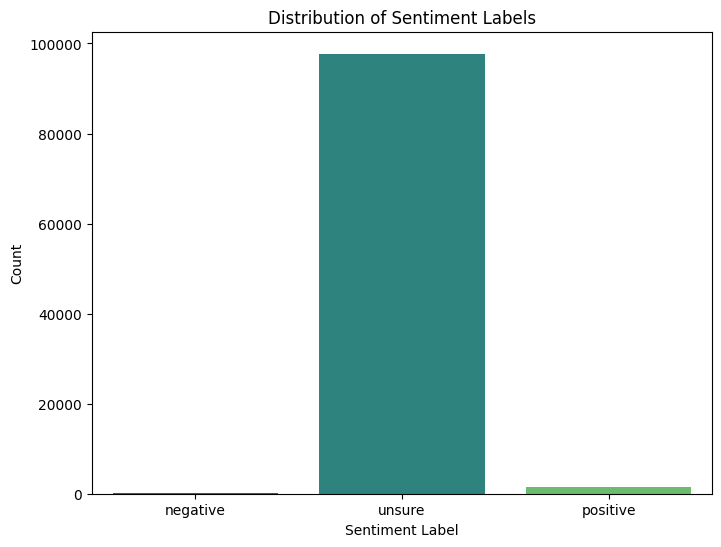

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='sentimen_label', data=data, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

In [78]:
mask = data['review_comment_translated'].notna()
data[mask].groupby('sentimen_label').apply(lambda x: x.sample(10))[['clean', 'sentimen']]

/tmp/ipykernel_12866/1131984984.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_12866/1131984984.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



clean  \
sentimen_label                                                            
negative       65014  dibutuhkan waktu yang berlebihan untuk masuk k...   
               25419  barang dagangan belum tiba absurd saya melakuk...   
               91137   saya memb dua lembar game hanya satu yang datang   
               47862  semuanya disampaikan sebelum tanggal produk de...   
               86344  saya memb produk reai dan menerima satu sepenu...   
               88101  saya tidak menerima produk saya dan saya juga ...   
               73078                                  pengiriman absurd   
               31060  saya memb game piec dan hanya menerima buah pe...   
               58608  pesan dengan item saya menerima item lain item...   
               12623  produk luar biasa yang dikirimkan oleh brasil ...   
unsure         41921                                        bagu sekali   
               91726  saat dibe oleh situ pihak ketiga dan pengirima...   
               42659                   butuh waktu untuk mengirimkannya   
               66659                      disampaikan sebelum kesehatan   
               45938  terima kasih ata kecepatan pengirimannya selal...   
               62666  saya menerima email yang menyatakan tidak terd...   
               97009                                    teknolog jepang   
               73111  warna dan cetakannya tidak sama dengan fotonya...   
               76467  saya menerima produk tetapi bukan apa yang say...   
               31600      saya menerima produk yang dibuang dengan baik   
positive       23584                produk hebat pengiriman super cepat   
               85537     super saya merekomendasikan dengan sangat baik   
               27902                                         ok gunakan   
               81820                             pengiriman super cepat   
               16323                             pengiriman super cepat   
               93578  produk telah tiba tepat waktu dan dikema denga...   
               75177  barang dagangan yang sangat bagu pengiriman su...   
               63843                 super merekomendasikan pertunjukan   
               91756     saya menerima pada tanggal yang benar semua ok   
               21504                             pengiriman super cepat   

                      sentimen  
sentimen_label                  
negative       65014 -0.500000  
               25419 -0.500000  
               91137 -0.400000  
               47862 -0.500000  
               86344 -0.500000  
               88101 -0.500000  
               73078 -0.500000  
               31060 -0.400000  
               58608 -0.400000  
               12623 -0.800000  
unsure         41921  0.000000  
               91726  0.000000  
               42659  0.000000  
               66659  0.000000  
               45938  0.000000  
               62666  0.000000  
               97009  0.000000  
               73111  0.000000  
               76467  0.000000  
               31600  0.000000  
positive       23584  0.333333  
               85537  0.333333  
               27902  0.500000  
               81820  0.333333  
               16323  0.333333  
               93578  0.500000  
               75177  0.333333  
               63843  0.333333  
               91756  0.500000  
               21504  0.333333

In [79]:
data_sample_negative = data[mask][data['sentimen_label'] == "negative"].sample(1000, replace=True)

/tmp/ipykernel_12866/1357953194.py:1: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



### Positive and Negative Reviews based on `review_score`

In [80]:
# Filter out reviews with no message
reviews_with_messages = data[data['review_comment_message'].notna()]

# Identify positive reviews (score 4 or 5)
positive_reviews = reviews_with_messages[reviews_with_messages['review_score'] >= 4]

# Identify negative reviews (score 1 or 2)
negative_reviews = reviews_with_messages[reviews_with_messages['review_score'] <= 2]

print("\n--- Sample of Positive Reviews (review_score >= 4) ---")
display(positive_reviews[['review_comment_message', 'review_score']].sample(min(5, len(positive_reviews))))

print("\n--- Sample of Negative Reviews (review_score <= 2) ---")
display(negative_reviews[['review_comment_message', 'review_score']].sample(min(5, len(negative_reviews))))


--- Sample of Positive Reviews (review_score >= 4) ---


,review_comment_message,review_score
57455,Recebi conforme descrito na internet.\r\nBoa q...,4
33779,Os correios estão demorando muito para entrega...,5
28380,otima loja recebi antes do prazo,4
21477,Obrigado pelo produto tudo certinho obrigado l...,5
2979,"Muito lindas, boa qualidade e ótimo preço !!",5



--- Sample of Negative Reviews (review_score <= 2) ---


,review_comment_message,review_score
51775,"Foram compradas 2 cadeiras, porém entregue som...",2
7150,Nao entregam no prazo!,1
43380,Não recebi o produto !,1
49970,Bom dia. Comprei o produto com previsão de ent...,1
67756,Não recebi o produto corretamente e não obtive...,1


In [81]:
print("\n--- Sample of Positive Reviews (review_score >= 4) ---")
display(positive_reviews[['review_comment_message', 'review_score']].sample(min(5, len(positive_reviews))))


--- Sample of Positive Reviews (review_score >= 4) ---


,review_comment_message,review_score
7358,"Produto de excelente qualidade, entregue antes...",5
29597,Recebi o meu pedido alguns dias da data previs...,5
20122,entrega muito rápida,5
74335,Amei! Do jeito que está na foto e chegou antes.,5
51769,Melhor tempo de entrega. Produto de excelente ...,5


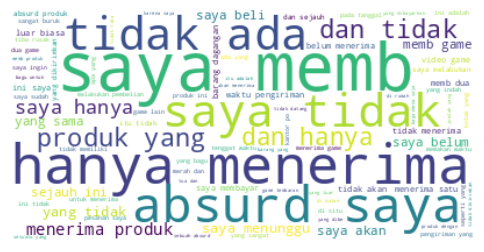

In [82]:
# Wordcloud
text = " ".join(text for text in data_sample_negative['clean'])
stopwords = set(STOPWORDS)
stopwords.update(
    ['still', 'come', 'na', 'bought', 'buy', 'made', 'got', 'base',
     'already'])  #Adding Stopword

# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,
                      background_color="white").generate(text)

# Display the generated image:
# the matplotlib way:
plt.rcParams["figure.figsize"] = (6, 4)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [83]:
total_reviews_with_messages = len(reviews_with_messages)

if total_reviews_with_messages > 0:
    positive_percentage = (len(positive_reviews) / total_reviews_with_messages) * 100
    negative_percentage = (len(negative_reviews) / total_reviews_with_messages) * 100

    print(f"Percentage of Positive Reviews (score 4 or 5): {positive_percentage:.2f}%")
    print(f"Percentage of Negative Reviews (score 1 or 2): {negative_percentage:.2f}%")
else:
    print("No reviews with messages found to calculate percentages.")

Percentage of Positive Reviews (score 4 or 5): 64.74%
Percentage of Negative Reviews (score 1 or 2): 26.58%


### Products with both Positive and Negative Reviews

In [84]:
# Merge positive_reviews with order_en to get product_id
positive_reviews_with_products = pd.merge(
    positive_reviews,
    order_en[['order_id', 'product_id', 'product_category_name_english']],
    on='order_id',
    how='left'
)

# Merge negative_reviews with order_en to get product_id
negative_reviews_with_products = pd.merge(
    negative_reviews,
    order_en[['order_id', 'product_id', 'product_category_name_english']],
    on='order_id',
    how='left'
)

positive_product_ids = positive_reviews_with_products['product_id'].unique()
negative_product_ids = negative_reviews_with_products['product_id'].unique()

# Find product IDs that appear in both positive and negative reviews
products_with_mixed_reviews = pd.Series(list(set(positive_product_ids) & set(negative_product_ids)))

if not products_with_mixed_reviews.empty:
    # Filter the original order_en to get information about these products
    mixed_review_products_data = order_en[order_en['product_id'].isin(products_with_mixed_reviews)]

    # Group by product_id and category to show products with their categories and mean review score
    product_summary = mixed_review_products_data.groupby(['product_id', 'product_category_name_english']).agg(
        average_review_score=('review_score', 'mean'),
        num_reviews=('review_score', 'count')
    ).reset_index()

    print(f"Found {len(products_with_mixed_reviews)} products with both positive and negative reviews.\n")
    print("--- Sample of Products with Mixed Reviews ---")
    display(product_summary.sort_values(by='num_reviews', ascending=False).head(10))
else:
    print("No products found with both positive and negative reviews.")

Found 1718 products with both positive and negative reviews.

--- Sample of Products with Mixed Reviews ---


,product_id,product_category_name_english,average_review_score,num_reviews
998,99a4788cb24856965c36a24e339b6058,bed_bath_table,3.889740,653
1138,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,4.004878,615
451,422879e10f46682990de24d770e7f83d,garden_tools,4.084211,475
1377,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,4.233853,449
385,389d119b48cf3043d311335e499d9c6b,garden_tools,4.064368,435
568,53759a2ecddad2bb87a079a1f1519f73,garden_tools,3.997685,432
571,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,4.248244,427
364,368c6c730842d78016ad823897a372db,garden_tools,4.113158,380
303,2b4609f8948be18874494203496bc318,health_beauty,4.054348,368
143,154e7e31ebfa092203795c972e5804a6,health_beauty,4.333333,357


# Product Recommendation System

In [85]:
order.head()

,order_id,order_status,order_products_value,order_freight_value,order_items_qty,order_sellers_qty,order_purchase_timestamp,order_aproved_at,order_estimated_delivery_date,order_delivered_customer_date,...,product_name_lenght,product_description_lenght,product_photos_qty,product_id,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,b95df3cef5297e79ef709ba256518f6f,delivered,349.90,13.84,1,1,2017-01-31 17:19:01,2017-02-01 02:41:21.549551,2017-03-15 00:00:00.000000,2017-02-06 11:04:24.154259,...,51,625,1,6cdd53843498f92890544667809f1595,b95df3cef5297e79ef709ba256518f6f,5,NaN,NaN,2017-02-07 00:00:00.000000,2017-02-09 02:37:37+00:00
1,59af46052a799e80e2f0c665c587731d,delivered,15.00,15.10,1,1,2017-09-09 19:52:54,2017-09-10 20:03:31.535281,2017-10-02 00:00:00.000000,2017-09-13 20:17:41.296915,...,44,1428,2,ae5cad88462eb7b7b61401e31c45618e,59af46052a799e80e2f0c665c587731d,5,NaN,entrega em 2 dias produto c boa qualidade otim...,2017-09-14 00:00:00.000000,2017-09-15 03:43:47+00:00
2,a3e6136894621db402a772c6bc72a12a,delivered,238.90,18.00,1,1,2017-01-30 17:00:09,2017-01-30 17:31:25.438253,2017-03-07 00:00:00.000000,2017-02-06 15:43:04.758566,...,55,637,1,0c9ff9d8ed9b9bdd825487b3a66e05f5,a3e6136894621db402a772c6bc72a12a,5,NaN,produto veio antes do prazo informado muito ob...,2017-02-07 00:00:00.000000,2017-02-10 14:18:53+00:00
3,b675ea5a618922f6e679e30531b8957b,delivered,29.99,18.23,1,1,2018-03-11 18:18:36,2018-03-11 18:30:37.931962,2018-04-03 00:00:00.000000,2018-04-03 20:36:43.778451,...,55,617,1,ad0a798e7941f3a5a2fb8139cb62ad78,b675ea5a618922f6e679e30531b8957b,4,NaN,NaN,2018-04-04 00:00:00.000000,2018-04-05 02:52:31+00:00
4,195a8be6794c487fe6cfbb97b7c61902,delivered,295.99,47.65,1,1,2017-04-20 08:01:08,2017-04-25 08:05:40.405383,2017-05-24 00:00:00.000000,2017-05-04 18:47:45.721758,...,49,558,2,eaf2046d4c87809247a30050ea13df03,195a8be6794c487fe6cfbb97b7c61902,5,NaN,NaN,2017-05-05 00:00:00.000000,2017-05-08 15:20:18+00:00


In [86]:
order_rating = order.loc[:, ['customer_id', 'product_id', 'review_score']]

In [87]:
order_rating = order_rating[order_rating['product_id'].isin(
    order_rating['product_id'].value_counts()[
        order_rating['product_id'].value_counts() > 10].index)]

In [88]:
order_rating = order_rating.reset_index()

In [89]:
ratings_utility_matrix = order_rating.pivot_table(values='review_score',
                                                  index='customer_id',
                                                  columns='product_id',
                                                  fill_value=0)
ratings_utility_matrix.head()

product_id,001b72dfd63e9833e8c02742adf472e3,00250175f79f584c14ab5cecd80553cd,005030ef108f58b46b78116f754d8d38,008cff0e5792219fae03e570f980b330,00ba6d766f0b1d7b78a5ce3e1e033263,00baba5b58e274d0332a0c8a0a66f877,00de7f393d962717eeeb2d7131a40dba,00faa46f36261af8bbf3a4d37fa4841b,0110573bc9195aa810a4384f189f48f5,014a8a503291921f7b004a5215bb3c36,...,fe95eb948375116da759c8ef60295001,fe9dfbe7f974621789683b7b78be2a16,fecf6223a3494f35362f670e571d2a04,fed5c40c27e1c88560a9e92d82ee0825,feee7d52babf4002f100a79183eb7989,ff55834c0b3272853dfe62340f2bb91b,ff5f8606556b625613f069a5a9a48966,ff7fccf8513f360157f0660fe51d1d88,ffb97eb64c6fe1baada2410288c04457,ffc9caf33e2d1e9f44e3e06da19085f7
customer_id,,,,,,,,,,,,,,,,,,,,,
00012a2ce6f8dcda20d059ce98491703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0001dad3e429b2831bf4e392170a8e8c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00031a627dcb899baea17e751172bef3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000379cdec625522490c315e70c7a9fb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00038477de4e0f0ac327ae1dc2f273c3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [90]:
ratings_utility_matrix.shape

(50012, 1651)

In [91]:
X = ratings_utility_matrix.T
X.head()

customer_id,00012a2ce6f8dcda20d059ce98491703,0001dad3e429b2831bf4e392170a8e8c,00031a627dcb899baea17e751172bef3,000379cdec625522490c315e70c7a9fb,00038477de4e0f0ac327ae1dc2f273c3,0004164d20a9e969af783496f3408652,0004e8e0600daf29de26bd60b8feb007,000c88c401a87f064691b4bea3eb86b4,000e943451fc2788ca6ac98a682f2f49,000eac74d62085b7026a068cfa46b3e3,...,fff5169e583fd07fac9fec88962f189d,fff55ba8dffa552b6fdfd86c2e806459,fff5ca85c16ebb7e531dbd4a08756567,fff7466a253c0e59499ea943462c10f9,fff9b667c8b07d8f3a9b45e60cb16e20,fffbc3192c60df9a7434b4cb1695fb18,fffecc9f79fd8c764f843e9951b11341,ffff42319e9b2d713724ae527742af25,ffffa3172527f765de70084a7e53aae8,ffffdd34d58526db84c9eeb26bb38e4f
product_id,,,,,,,,,,,,,,,,,,,,,
001b72dfd63e9833e8c02742adf472e3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00250175f79f584c14ab5cecd80553cd,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
005030ef108f58b46b78116f754d8d38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
008cff0e5792219fae03e570f980b330,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00ba6d766f0b1d7b78a5ce3e1e033263,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [92]:
X.shape

(1651, 50012)

In [93]:
def fitsystemrecommendation(ratings_utility_matrix):
    X = ratings_utility_matrix.T
    SVD = TruncatedSVD(n_components=10)
    decomposed_matrix = SVD.fit_transform(X)
    correlation_matrix = np.corrcoef(decomposed_matrix)
    return correlation_matrix

In [94]:
correlation_matrix = fitsystemrecommendation(ratings_utility_matrix)

In [95]:
def systemrecommendation(prod_id):
    order_rating.index[order_rating['product_id'] == prod_id].tolist()[0] # Changed index to [0] to avoid potential error if only one match
    product_names = list(X.index)
    product_ID = product_names.index(prod_id)
    correlation_product_ID = correlation_matrix[product_ID]

    # Get recommended product_ids
    recommended_product_ids = list(X.index[correlation_product_ID > 0.70])

    # Remove the input product itself from recommendations
    if prod_id in recommended_product_ids:
        recommended_product_ids.remove(prod_id)

    # Filter order_en to get category names and review scores for recommended products
    recommended_products_data = order_en[order_en['product_id'].isin(recommended_product_ids)][['product_id', 'product_category_name_english', 'review_score']].drop_duplicates()

    # Group by category and calculate average review score
    recommended_categories_with_ratings = recommended_products_data.groupby('product_category_name_english')['review_score'].mean().reset_index()
    recommended_categories_with_ratings.columns = ['Recommendation Category', 'Average Rating']

    # Take top 9 unique category names (if more than 9 unique categories exist)
    # Sort by rating and then take top N
    recommended_categories_with_ratings = recommended_categories_with_ratings.sort_values(by='Average Rating', ascending=False).head(9)

    return recommended_categories_with_ratings


In [96]:
systemrecommendation('001b72dfd63e9833e8c02742adf472e3')

,Recommendation Category,Average Rating
4,books_technical,4.000000
11,food_drink,4.000000
26,stationery,3.888889
27,telephony,3.571429
18,home_confort,3.500000
17,home_appliances_2,3.375000
6,cool_stuff,3.368421
16,home_appliances,3.333333
24,pet_shop,3.333333


In [97]:
import pandas as pd

# Load data
df = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/reviews_translated.csv')
geo = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/geolocation_data_set.csv')
order = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/Review.csv')
cust = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/olist_public_dataset_v2_customers.csv')
pay = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/payment data.csv')
trans = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/Translation.csv')

# Basic quick cleaning
df = df.drop_duplicates()
df = df.fillna(method='ffill')  # fast fill

# Convert dates automatically
for col in df.columns:
    try:
        df[col] = pd.to_datetime(df[col])
    except:
        pass

# Quick summary
print(df.describe(include='all'))

# Save cleaned file
df.to_csv("cleaned_data.csv", index=False)

/tmp/ipykernel_12866/3403013346.py:13: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_12866/3403013346.py:18: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_12866/3403013346.py:18: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_12866/3403013346.py:18: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_12866/3403013346.py:18: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`

                               review_id                          order_id  \
count                              99224                             99224   
unique                             98410                             98673   
top     4548534449b1f572e357211b90724f1b  03c939fd7fd3b38f8485a0f95798f1f6   
freq                                   3                                 3   
mean                                 NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

                         review_score review_comment_title  \
count                           99224                99215   
unique           

In [98]:
# Re-load df to ensure order_id is present for merging
df = pd.read_csv('/content/drive/MyDrive/Customer Sentiment/reviews_translated.csv')

# Select columns including order_id
df_cols = [col for col in ['review_id', 'order_id', 'review_score', 'review_comment_message', 'review_comment_translated'] if col in df.columns]
df = df[df_cols]

# Select columns for other DataFrames
order = order[['order_id', 'product_id', 'customer_id', 'order_status', 'order_products_value',
               'order_freight_value', 'order_items_qty', 'order_sellers_qty', 'order_purchase_timestamp',
               'product_category_name']]
cust = cust[['customer_id','customer_unique_id']]
pay = pay[['order_id', 'sequential', 'payment_type', 'installments']]

print("Keys check - df has order_id:", 'order_id' in df.columns)
print("Keys check - order has order_id:", 'order_id' in order.columns)

Keys check - df has order_id: True
Keys check - order has order_id: True


In [99]:
# Merge reviews + orders
data = df.merge(order, on='order_id', how='left')

# Merge payments
data = data.merge(pay, on='order_id', how='left')

# Merge customers
if 'customer_id' in data.columns and 'customer_id' in cust.columns:
    data = data.merge(cust, on='customer_id', how='left')

print("Merged data shape:", data.shape)
data.head()

Merged data shape: (112030, 18)


,review_id,order_id,review_score,review_comment_message,review_comment_translated,product_id,customer_id,order_status,order_products_value,order_freight_value,order_items_qty,order_sellers_qty,order_purchase_timestamp,product_category_name,sequential,payment_type,installments,customer_unique_id
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,be0dbdc3d67d55727a65d4cd696ca73c,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,79.79,8.30,1.0,1.0,2018-02-28 12:25:19.000000,informatica_acessorios,1.0,credit_card,1.0,db181927d34d6ceffaafd9b10dad028f
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,d1c427060a0f73f6b889a5c7c61f2ac4,e226dfed6544df5b7b87a48208690feb,delivered,149.00,45.12,1.0,1.0,2018-02-03 09:56:22.000000,informatica_acessorios,1.0,credit_card,1.0,d0987a776fe151fbed480070f115fb13
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.,Saya menerima jauh sebelum tenggat waktu.,52c80cedd4e90108bf4fa6a206ef6b03,de6dff97e5f1ba84a3cd9a3bc97df5f6,delivered,179.99,42.85,1.0,1.0,2017-04-09 17:41:13.000000,ferramentas_jardim,1.0,credit_card,1.0,22dc6d21a43f93421f311a9ba2246f06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela I...,Selamat Toko Lannister Saya suka membeli inter...,3880d25d502b15b1de6fddc42ad1d67a,5986b333ca0d44534a156a52a8e33a83,delivered,1199.00,134.25,1.0,1.0,2018-02-10 10:59:03.000000,esporte_lazer,1.0,credit_card,10.0,85d945b43bec4cd88a78a183057d1ff6


In [100]:
# Ensure monetary values are numeric and handle NaN/string values
data['order_products_value'] = pd.to_numeric(data['order_products_value'], errors='coerce').fillna(0)

# Ensure timestamp is datetime
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'], errors='coerce')
reference_date = data['order_purchase_timestamp'].max()

# Group by unique customer to calculate metrics
rfm_data = data.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'order_products_value': 'sum'
}).reset_index()

rfm_data.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

# Assign scores (1-5) using quantiles; duplicates='drop' handles clusters of identical values
rfm_data['R_Score'] = pd.qcut(rfm_data['recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm_data['F_Score'] = pd.cut(rfm_data['frequency'], bins=[0, 1, 2, 5, 10, 100], labels=[1, 2, 3, 4, 5], include_lowest=True)
rfm_data['M_Score'] = pd.qcut(rfm_data['monetary'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Merge these scores back into the main 'data' DataFrame
# We use suffixes to avoid overlap if the columns already exist from a previous failed run
data = data.merge(rfm_data[['customer_unique_id', 'recency', 'frequency', 'monetary', 'R_Score', 'F_Score', 'M_Score']],
                  on='customer_unique_id', how='left', suffixes=('', '_rfm'))

# --- Start of Sentiment Analysis Integration ---
col_to_translate = 'review_comment_translated'

if col_to_translate in data.columns:
    data['clean'] = data[col_to_translate].apply(
        lambda x: clean_text(cleaner(str(x))) if pd.notnull(x) else ''
    )
else:
    print(f"Column '{col_to_translate}' not found. Cannot perform sentiment analysis.")
    data['clean'] = '' # Initialize clean to avoid further errors

if 'clean' in data.columns:
    data['sentimen'] = data['clean'].apply(
        lambda x: sentimen_en(x) if pd.notnull(x) else 0.0
    )
else:
    data['sentimen'] = 0.0

bins = [-1, -0.3, 0.3, 1]
labels = ['negative', 'unsure', 'positive']
data['sentimen_label'] = pd.cut(
    data['sentimen'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
# --- End of Sentiment Analysis Integration ---

print("RFMT scores integrated successfully.")
# Displaying columns from the merged result
print(data[['customer_unique_id', 'sentimen', 'recency', 'R_Score', 'M_Score']].head())

RFMT scores integrated successfully.
                 customer_unique_id  sentimen  recency R_Score M_Score
0                               NaN       0.0      NaN     NaN     NaN
1  db181927d34d6ceffaafd9b10dad028f       0.0    181.0       4       3
2  d0987a776fe151fbed480070f115fb13       0.0    207.0       4       4
3  22dc6d21a43f93421f311a9ba2246f06       0.0    506.0       1       4
4  85d945b43bec4cd88a78a183057d1ff6       0.0    199.0       4       5


In [101]:
# Ensure monetary values are numeric and handle NaN/string values from previous steps
data['order_products_value'] = pd.to_numeric(data['order_products_value'], errors='coerce').fillna(0)

# Ensure timestamp is datetime
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'], errors='coerce')
reference_date = data['order_purchase_timestamp'].max()

# Group by unique customer to calculate metrics
rfm_data = data.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'order_products_value': 'sum'
}).reset_index()

rfm_data.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

# Assign scores (1-5) using quantiles; duplicates='drop' handles clusters of identical values
rfm_data['R_Score'] = pd.qcut(rfm_data['recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm_data['F_Score'] = pd.cut(rfm_data['frequency'], bins=[0, 1, 2, 5, 10, 100], labels=[1, 2, 3, 4, 5], include_lowest=True)
rfm_data['M_Score'] = pd.qcut(rfm_data['monetary'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Merge these scores back into the main 'data' DataFrame
data = data.merge(rfm_data[['customer_unique_id', 'recency', 'frequency', 'monetary', 'R_Score', 'F_Score', 'M_Score']],
                  on='customer_unique_id', how='left', suffixes=('', '_rfm'))

print('RFMT scores integrated successfully.')
data[['customer_unique_id', 'sentimen', 'recency', 'R_Score', 'M_Score']].head()

RFMT scores integrated successfully.


,customer_unique_id,sentimen,recency,R_Score,M_Score
0,NaN,0.0,NaN,NaN,NaN
1,db181927d34d6ceffaafd9b10dad028f,0.0,181.0,4,3
2,d0987a776fe151fbed480070f115fb13,0.0,207.0,4,4
3,22dc6d21a43f93421f311a9ba2246f06,0.0,506.0,1,4
4,85d945b43bec4cd88a78a183057d1ff6,0.0,199.0,4,5


In [102]:
data.to_csv("final_dashboard_data.csv", index=False)

In [103]:
# To downloads file from Google Colab to your local system.

# from google.colab import files
# files.download("final_dashboard_data.csv")

In [104]:
data.to_csv("/content/drive/MyDrive/final_dashboard_data.csv", index=False)

In [105]:
pip install flask_cors

In [106]:
# Install all required libraries
!pip install -q flask flask-cors transformers pyngrok

# Kill any process running on port 5000
!fuser -k 5000/tcp

# Imports
import threading
from flask import Flask, request, jsonify
from flask_cors import CORS
from transformers import pipeline
from pyngrok import ngrok
from getpass import getpass

# ---------------------------
# 🔐 NGROK AUTHENTICATION
# ---------------------------
print("👉 Paste your ngrok auth token:")
token = getpass()
ngrok.set_auth_token(token)

# ---------------------------
# 🤖 LOAD MODEL
# ---------------------------
print("⏳ Loading sentiment model...")
model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)
print("✅ Model loaded successfully!")

# ---------------------------
# 🌐 FLASK APP
# ---------------------------
app = Flask(__name__)
CORS(app)

@app.route("/")
def home():
    return "🚀 Sentiment Analysis API is Running!"

@app.route("/analyze", methods=["POST"])
def analyze():
    data = request.get_json()
    text = data.get("text", "")

    if not text:
        return jsonify({"error": "No text provided"}), 400

    result = model(text)[0]
    return jsonify({
        "text": text,
        "sentiment": result["label"],
        "confidence": float(result["score"])
    })

# ---------------------------
# ▶️ RUN SERVER
# ---------------------------
def run():
    app.run(port=5000)

threading.Thread(target=run).start()

# ---------------------------
# 🌍 START NGROK
# ---------------------------
public_url = ngrok.connect(addr=5000)

print("\n🚀 YOUR API IS LIVE!")
print("🌐 URL:", public_url)
print("📌 Endpoint:", str(public_url) + "/analyze")

👉 Paste your ngrok auth token:
··········
⏳ Loading sentiment model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model loaded successfully!
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit



🚀 YOUR API IS LIVE!
🌐 URL: NgrokTunnel: "https://eradicate-overlook-singer.ngrok-free.dev" -> "http://localhost:5000"
📌 Endpoint: NgrokTunnel: "https://eradicate-overlook-singer.ngrok-free.dev" -> "http://localhost:5000"/analyze


In [107]:
# GoTo -> https://dashboard.ngrok.com?utm_source=chatgpt.com
# Login -> Your AutoToken -> Generate Token